# 02 - Leakage-Safe Grouped Model Validation

This notebook compares three candidate classifiers for drive-failure prediction:

- Logistic Regression
- Random Forest
- XGBoost

The main goal is to select a stable baseline using **five-fold `StratifiedGroupKFold` validation**.

Each physical drive appears in multiple daily rows. The split therefore groups by `serial_number` so that observations from one drive cannot appear in both training and validation data within the same fold.

The notebook reports:

1. fold-level class balance and leakage checks;
2. training and validation ROC-AUC and PR-AUC;
3. train–validation gaps;
4. preliminary threshold-based precision, recall, and F1;
5. cross-fold stability;
6. the final baseline selection.

Threshold-dependent metrics in this notebook use `0.50` only as an initial diagnostic. Operational threshold selection is performed later using out-of-fold predictions and drive-level evaluation.

## Why grouped validation is necessary

A row represents one **drive-day**, not one independent physical device. The same `serial_number` may appear on many dates.

A random row split could place earlier observations from a drive in training and later observations from that same drive in validation. That would create **drive-identity leakage** and could make performance appear more optimistic than it would be on unseen drives.

`StratifiedGroupKFold` serves two purposes:

- **grouping:** keeps every physical drive in one fold;
- **stratification:** attempts to distribute the rare failure class across folds.

This grouped design controls identity overlap. It is not the same as a strict future-time holdout, which remains a limitation of the project.

In [1]:
from __future__ import annotations

from pathlib import Path
import gc
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 1. Configuration

The original completed comparison used:

- a reproducible 30% row sample;
- five grouped folds;
- three raw SMART features;
- `serial_number` as the grouping key;
- random state 42.

The 30% sample was used to keep the three-model, five-fold comparison computationally manageable on Kaggle.

In [2]:
DATA_PATH = Path(
    "/kaggle/input/datasets/emilywanglovescats/"
    "blackblaze-data-2023-cleaned/df_cleaned.parquet"
)

OUTPUT_DIR = Path("/kaggle/working")
FOLD_RESULTS_PATH = OUTPUT_DIR / "cv_fold_results.csv"
SUMMARY_PATH = OUTPUT_DIR / "cv_summary.csv"

TARGET_COLUMN = "failure"
GROUP_COLUMN = "serial_number"

FEATURE_COLUMNS = [
    "smart_5_raw",
    "smart_197_raw",
    "smart_198_raw",
]

SAMPLE_FRACTION = 0.30
N_SPLITS = 5
RANDOM_STATE = 42

# This threshold is used only for preliminary fold diagnostics.
# It is not the final operational threshold.
DIAGNOSTIC_THRESHOLD = 0.50

## 2. Load the cleaned dataset

Only the three baseline features, target, and grouping identifier are loaded into the working dataframe.

In [3]:
def load_data(
    file_path: Path,
    sample_fraction: float,
    random_state: int,
) -> pd.DataFrame:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Dataset not found at:\n{file_path}\n\n"
            "Update DATA_PATH to the location of df_cleaned.parquet."
        )

    if not 0 < sample_fraction <= 1:
        raise ValueError("sample_fraction must be in the interval (0, 1].")

    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN, GROUP_COLUMN]

    df = pd.read_parquet(
        file_path,
        columns=required_columns,
    )

    missing_columns = set(required_columns) - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"Dataset is missing required columns: {sorted(missing_columns)}"
        )

    if sample_fraction < 1.0:
        df = df.sample(
            frac=sample_fraction,
            random_state=random_state,
        ).reset_index(drop=True)

    if df[TARGET_COLUMN].nunique() < 2:
        raise ValueError(
            "The working sample contains only one target class. "
            "Increase SAMPLE_FRACTION."
        )

    if df[GROUP_COLUMN].isna().any():
        raise ValueError("serial_number contains missing values.")

    return df


df = load_data(
    file_path=DATA_PATH,
    sample_fraction=SAMPLE_FRACTION,
    random_state=RANDOM_STATE,
)

print(f"Working rows: {len(df):,}")
print(f"Unique drives: {df[GROUP_COLUMN].nunique():,}")
print(f"Positive rows: {int(df[TARGET_COLUMN].sum()):,}")
print(f"Failure prevalence: {df[TARGET_COLUMN].mean():.6%}")
print(
    f"Approximate memory usage: "
    f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB"
)

display(df.head())

Working rows: 7,437,300
Unique drives: 281,192
Positive rows: 324
Failure prevalence: 0.004356%
Approximate memory usage: 0.53 GB


,smart_5_raw,smart_197_raw,smart_198_raw,failure,serial_number
0,0.0,0.0,0.0,0,ZL2CRHCN
1,0.0,0.0,0.0,0,AAHM4H6H
2,0.0,0.0,0.0,0,ZTT3VRWC
3,0.0,0.0,0.0,0,X0GDJXLC
4,0.0,0.0,0.0,0,ZL2LMGEK


## 3. Separate features, target, and groups

`serial_number` is used only for splitting. It is not given to the models as a predictive feature.

In [4]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].astype("int8").copy()
groups = df[GROUP_COLUMN].copy()

del df
gc.collect()

print(f"Feature matrix shape: {X.shape}")
print(f"Target positives: {int(y.sum()):,}")
print(f"Grouping entities: {groups.nunique():,}")

Feature matrix shape: (7437300, 3)
Target positives: 324
Grouping entities: 281,192


## 4. Model definitions

All three models use class-imbalance handling:

- Logistic Regression: `class_weight="balanced"`
- Random Forest: `class_weight="balanced"`
- XGBoost: `scale_pos_weight = negatives / positives` within each training fold

Logistic Regression also standardizes the numeric features because its optimization is scale-sensitive. Tree models do not require scaling.

In [5]:
def create_logistic_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def create_random_forest_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=15,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def calculate_scale_pos_weight(y_train: pd.Series) -> float:
    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())

    if positive_count == 0:
        raise ValueError("Training fold contains no positive examples.")

    return negative_count / positive_count


def create_xgboost_pipeline(scale_pos_weight: float) -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                XGBClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=5,
                    objective="binary:logistic",
                    eval_metric="aucpr",
                    scale_pos_weight=scale_pos_weight,
                    tree_method="hist",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

## 5. Evaluation metrics

Because failures are extremely rare, accuracy is not used as the main selection metric.

- **ROC-AUC** measures ranking performance across thresholds, but it can look favorable when the negative class is enormous.
- **PR-AUC** emphasizes performance on the rare positive class and is therefore especially important here.
- **Precision, recall, and F1** are reported at a temporary threshold of 0.50 only as diagnostics.
- **Train–validation gaps** help identify whether a model fits the training folds much better than unseen validation drives.

A small gap does not prove that overfitting is impossible. It is evidence that the model's training and validation ranking behavior is relatively similar under this validation design.

In [6]:
def evaluate_scores(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    predictions = (probabilities >= threshold).astype("int8")

    return {
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
    }


def fit_and_evaluate(
    model: BaseEstimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    threshold: float,
) -> tuple[dict[str, float], dict[str, float], float]:
    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    fit_seconds = time.perf_counter() - start_time

    train_probabilities = model.predict_proba(X_train)[:, 1]
    valid_probabilities = model.predict_proba(X_valid)[:, 1]

    train_metrics = evaluate_scores(
        y_true=y_train,
        probabilities=train_probabilities,
        threshold=threshold,
    )
    valid_metrics = evaluate_scores(
        y_true=y_valid,
        probabilities=valid_probabilities,
        threshold=threshold,
    )

    return train_metrics, valid_metrics, fit_seconds

## 6. Run five-fold `StratifiedGroupKFold`

A fresh instance of each model is trained in every fold.

Before training, the notebook verifies that the training and validation serial-number sets have zero overlap.

In [7]:
splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_records: list[dict[str, float | int | str]] = []

for fold, (train_index, valid_index) in enumerate(
    splitter.split(X, y, groups=groups)
):
    X_train = X.iloc[train_index]
    X_valid = X.iloc[valid_index]
    y_train = y.iloc[train_index]
    y_valid = y.iloc[valid_index]

    train_groups = set(groups.iloc[train_index])
    valid_groups = set(groups.iloc[valid_index])
    group_overlap = train_groups.intersection(valid_groups)

    if group_overlap:
        raise RuntimeError(
            f"Leakage detected in Fold {fold}: "
            f"{len(group_overlap)} drives appear in both partitions."
        )

    print("\n" + "=" * 78)
    print(f"FOLD {fold + 1}/{N_SPLITS}")
    print("=" * 78)
    print(f"Training rows: {len(X_train):,}")
    print(f"Validation rows: {len(X_valid):,}")
    print(f"Training drives: {len(train_groups):,}")
    print(f"Validation drives: {len(valid_groups):,}")
    print(f"Training positives: {int(y_train.sum()):,}")
    print(f"Validation positives: {int(y_valid.sum()):,}")
    print(f"Training prevalence: {y_train.mean():.6%}")
    print(f"Validation prevalence: {y_valid.mean():.6%}")
    print(f"Serial-number overlap: {len(group_overlap)}")

    scale_pos_weight = calculate_scale_pos_weight(y_train)

    models = {
        "Logistic Regression": create_logistic_pipeline(),
        "Random Forest": create_random_forest_pipeline(),
        "XGBoost": create_xgboost_pipeline(
            scale_pos_weight=scale_pos_weight
        ),
    }

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        train_metrics, valid_metrics, fit_seconds = fit_and_evaluate(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_valid=X_valid,
            y_valid=y_valid,
            threshold=DIAGNOSTIC_THRESHOLD,
        )

        record = {
            "fold": fold,
            "model": model_name,
            "train_rows": len(X_train),
            "validation_rows": len(X_valid),
            "train_drives": len(train_groups),
            "validation_drives": len(valid_groups),
            "train_positives": int(y_train.sum()),
            "validation_positives": int(y_valid.sum()),
            "train_failure_rate": float(y_train.mean()),
            "validation_failure_rate": float(y_valid.mean()),
            "serial_overlap": len(group_overlap),
            "train_roc_auc": train_metrics["roc_auc"],
            "validation_roc_auc": valid_metrics["roc_auc"],
            "roc_auc_gap": (
                train_metrics["roc_auc"]
                - valid_metrics["roc_auc"]
            ),
            "train_pr_auc": train_metrics["pr_auc"],
            "validation_pr_auc": valid_metrics["pr_auc"],
            "pr_auc_gap": (
                train_metrics["pr_auc"]
                - valid_metrics["pr_auc"]
            ),
            "validation_precision_at_050": valid_metrics["precision"],
            "validation_recall_at_050": valid_metrics["recall"],
            "validation_f1_at_050": valid_metrics["f1"],
            "fit_seconds": fit_seconds,
        }
        fold_records.append(record)

        print(
            f"Train ROC-AUC: {train_metrics['roc_auc']:.6f} | "
            f"Validation ROC-AUC: {valid_metrics['roc_auc']:.6f} | "
            f"Gap: {record['roc_auc_gap']:.6f}"
        )
        print(
            f"Train PR-AUC: {train_metrics['pr_auc']:.6f} | "
            f"Validation PR-AUC: {valid_metrics['pr_auc']:.6f} | "
            f"Gap: {record['pr_auc_gap']:.6f}"
        )
        print(
            f"Validation precision@0.50: "
            f"{valid_metrics['precision']:.6f}"
        )
        print(
            f"Validation recall@0.50: "
            f"{valid_metrics['recall']:.6f}"
        )
        print(f"Fit time: {fit_seconds:.2f} seconds")

        del model
        gc.collect()

    del X_train, X_valid, y_train, y_valid, models
    gc.collect()

cv_fold_results = pd.DataFrame(fold_records)

print("\nFive-fold training completed.")
display(
    cv_fold_results.sort_values(["model", "fold"]).reset_index(drop=True)
)


FOLD 1/5
Training rows: 5,949,552
Validation rows: 1,487,748
Training drives: 224,953
Validation drives: 56,239
Training positives: 262
Validation positives: 62
Training prevalence: 0.004404%
Validation prevalence: 0.004167%
Serial-number overlap: 0

Training Logistic Regression...
Train ROC-AUC: 0.879950 | Validation ROC-AUC: 0.780333 | Gap: 0.099617
Train PR-AUC: 0.006241 | Validation PR-AUC: 0.007356 | Gap: -0.001115
Validation precision@0.50: 0.002223
Validation recall@0.50: 0.483871
Fit time: 11.79 seconds

Training Random Forest...
Train ROC-AUC: 0.883825 | Validation ROC-AUC: 0.433646 | Gap: 0.450180
Train PR-AUC: 0.002339 | Validation PR-AUC: 0.000136 | Gap: 0.002203
Validation precision@0.50: 0.000265
Validation recall@0.50: 0.145161
Fit time: 130.69 seconds

Training XGBoost...
Train ROC-AUC: 0.885348 | Validation ROC-AUC: 0.509426 | Gap: 0.375923
Train PR-AUC: 0.067340 | Validation PR-AUC: 0.005530 | Gap: 0.061811
Validation precision@0.50: 0.000398
Validation recall@0.50: 

,fold,model,train_rows,validation_rows,train_drives,validation_drives,train_positives,validation_positives,train_failure_rate,validation_failure_rate,...,train_roc_auc,validation_roc_auc,roc_auc_gap,train_pr_auc,validation_pr_auc,pr_auc_gap,validation_precision_at_050,validation_recall_at_050,validation_f1_at_050,fit_seconds
0,0,Logistic Regression,5949552,1487748,224953,56239,262,62,0.000044,0.000042,...,0.879950,0.780333,0.099617,0.006241,0.007356,-0.001115,0.002223,0.483871,0.004425,11.790162
1,1,Logistic Regression,5948343,1488957,224950,56242,260,64,0.000044,0.000043,...,0.860958,0.904440,-0.043482,0.006650,0.006973,-0.000323,0.002634,0.593750,0.005246,12.221991
2,2,Logistic Regression,5951962,1485338,224957,56235,270,54,0.000045,0.000036,...,0.869268,0.870999,-0.001731,0.006430,0.006135,0.000295,0.002259,0.555556,0.004500,11.636362
3,3,Logistic Regression,5948784,1488516,224954,56238,246,78,0.000041,0.000052,...,0.855820,0.912582,-0.056762,0.006518,0.005673,0.000845,0.002467,0.487179,0.004909,11.631114
4,4,Logistic Regression,5950559,1486741,224954,56238,258,66,0.000043,0.000044,...,0.878036,0.823103,0.054933,0.006165,0.006577,-0.000411,0.002483,0.500000,0.004942,11.653959
5,0,Random Forest,5949552,1487748,224953,56239,262,62,0.000044,0.000042,...,0.883825,0.433646,0.450180,0.002339,0.000136,0.002203,0.000265,0.145161,0.000529,130.685932
6,1,Random Forest,5948343,1488957,224950,56242,260,64,0.000044,0.000043,...,0.864584,0.430394,0.434190,0.001635,0.000308,0.001327,0.000498,0.171875,0.000994,131.186263
7,2,Random Forest,5951962,1485338,224957,56235,270,54,0.000045,0.000036,...,0.874436,0.469466,0.404970,0.002259,0.000202,0.002058,0.000266,0.166667,0.000531,130.689406
8,3,Random Forest,5948784,1488516,224954,56238,246,78,0.000041,0.000052,...,0.859726,0.311335,0.548391,0.001478,0.000241,0.001237,0.000479,0.128205,0.000954,130.259791
9,4,Random Forest,5950559,1486741,224954,56238,258,66,0.000043,0.000044,...,0.884936,0.424824,0.460113,0.001719,0.000149,0.001570,0.000356,0.090909,0.000709,131.196806


## 7. Cross-fold summary

The summary reports mean performance and fold-to-fold standard deviation.

Lower standard deviation indicates more consistent behavior across validation folds. The train–validation gap columns provide an additional overfitting diagnostic.

In [8]:
cv_summary = (
    cv_fold_results
    .groupby("model")
    .agg(
        validation_roc_auc_mean=("validation_roc_auc", "mean"),
        validation_roc_auc_std=("validation_roc_auc", "std"),
        validation_pr_auc_mean=("validation_pr_auc", "mean"),
        validation_pr_auc_std=("validation_pr_auc", "std"),
        train_roc_auc_mean=("train_roc_auc", "mean"),
        train_pr_auc_mean=("train_pr_auc", "mean"),
        roc_auc_gap_mean=("roc_auc_gap", "mean"),
        roc_auc_gap_std=("roc_auc_gap", "std"),
        pr_auc_gap_mean=("pr_auc_gap", "mean"),
        pr_auc_gap_std=("pr_auc_gap", "std"),
        precision_at_050_mean=(
            "validation_precision_at_050",
            "mean",
        ),
        precision_at_050_std=(
            "validation_precision_at_050",
            "std",
        ),
        recall_at_050_mean=(
            "validation_recall_at_050",
            "mean",
        ),
        recall_at_050_std=(
            "validation_recall_at_050",
            "std",
        ),
        f1_at_050_mean=("validation_f1_at_050", "mean"),
        f1_at_050_std=("validation_f1_at_050", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
    )
    .sort_values("validation_pr_auc_mean", ascending=False)
)

display(cv_summary)

,validation_roc_auc_mean,validation_roc_auc_std,validation_pr_auc_mean,validation_pr_auc_std,train_roc_auc_mean,train_pr_auc_mean,roc_auc_gap_mean,roc_auc_gap_std,pr_auc_gap_mean,pr_auc_gap_std,precision_at_050_mean,precision_at_050_std,recall_at_050_mean,recall_at_050_std,f1_at_050_mean,f1_at_050_std,fit_seconds_mean
model,,,,,,,,,,,,,,,,,
XGBoost,0.554590,0.030146,0.011351,0.008317,0.875608,0.082481,0.321018,0.031712,0.071130,0.015355,0.000756,0.000273,0.357839,0.059773,0.001509,0.000545,78.800192
Logistic Regression,0.858291,0.056023,0.006543,0.000665,0.868806,0.006401,0.010515,0.066151,-0.000142,0.000744,0.002413,0.000171,0.524071,0.048484,0.004804,0.000339,11.786718
Random Forest,0.413933,0.059976,0.000207,0.000071,0.873501,0.001886,0.459569,0.053858,0.001679,0.000433,0.000373,0.000112,0.140563,0.032792,0.000743,0.000223,130.803639


## 8. Stability visualizations

These plots show validation ranking performance across folds. They are intended to reveal both average performance and fold-to-fold variability rather than highlighting only the best fold.

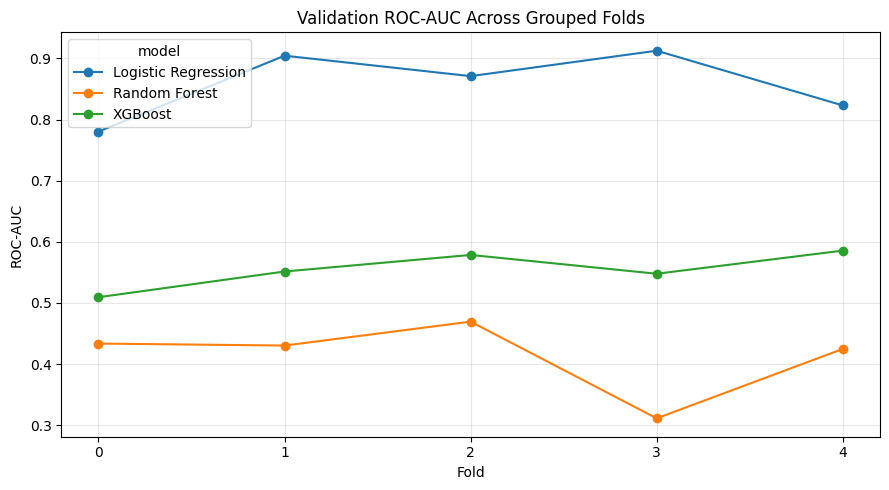

In [9]:
roc_plot = cv_fold_results.pivot(
    index="fold",
    columns="model",
    values="validation_roc_auc",
)

ax = roc_plot.plot(marker="o", figsize=(9, 5))
ax.set_title("Validation ROC-AUC Across Grouped Folds")
ax.set_xlabel("Fold")
ax.set_ylabel("ROC-AUC")
ax.set_xticks(range(N_SPLITS))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

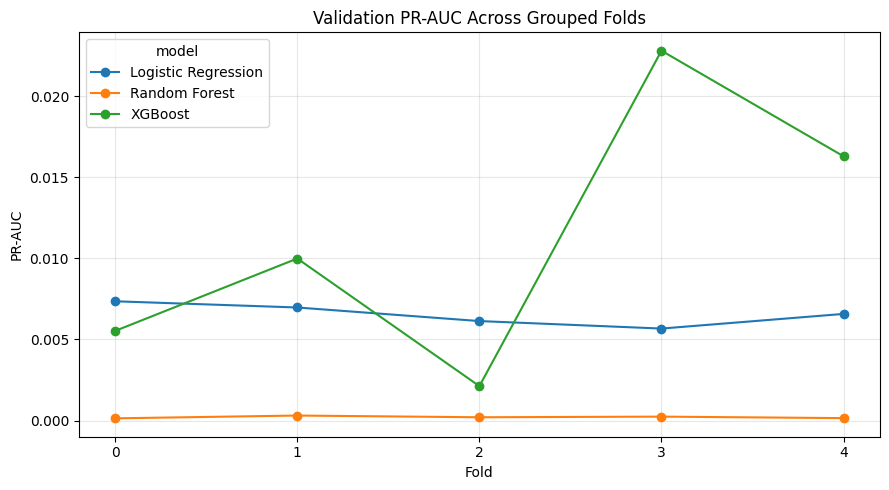

In [10]:
pr_plot = cv_fold_results.pivot(
    index="fold",
    columns="model",
    values="validation_pr_auc",
)

ax = pr_plot.plot(marker="o", figsize=(9, 5))
ax.set_title("Validation PR-AUC Across Grouped Folds")
ax.set_xlabel("Fold")
ax.set_ylabel("PR-AUC")
ax.set_xticks(range(N_SPLITS))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

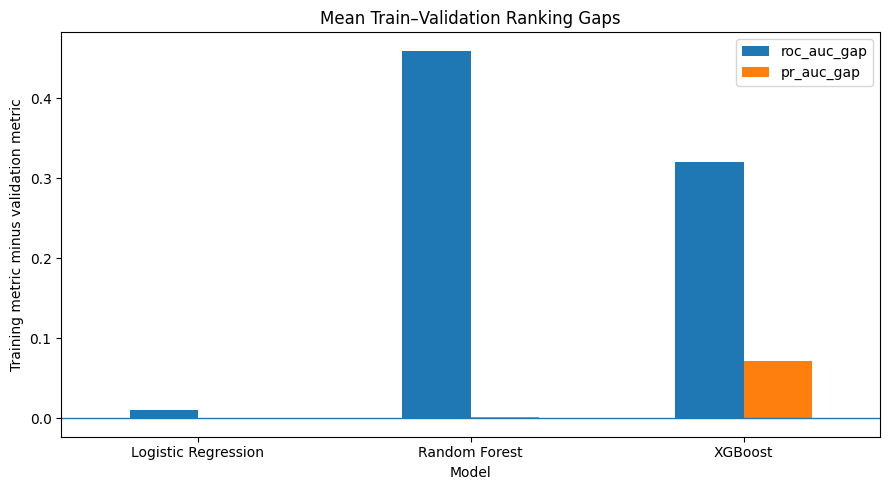

In [11]:
gap_summary = (
    cv_fold_results
    .groupby("model")[["roc_auc_gap", "pr_auc_gap"]]
    .mean()
)

ax = gap_summary.plot(kind="bar", figsize=(9, 5))
ax.set_title("Mean Train–Validation Ranking Gaps")
ax.set_xlabel("Model")
ax.set_ylabel("Training metric minus validation metric")
ax.axhline(0, linewidth=1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 9. Interpreting the comparison

The models should not be selected from one number alone.

The completed experiment showed the following overall pattern:

- XGBoost achieved the highest recorded mean PR-AUC, but its PR-AUC varied substantially across folds.
- Logistic Regression produced stronger mean ROC-AUC and much more consistent PR-AUC across folds.
- Logistic Regression also showed a comparatively small train–validation ranking gap.
- Random Forest and XGBoost showed weaker or less stable generalization under this feature set and validation design.
- Metrics at threshold 0.50 were treated as preliminary because the final operating threshold had not yet been selected.

“Stable” means that the Logistic Regression results were comparatively consistent across grouped folds and that its training metrics were not dramatically better than its validation metrics. It does **not** mean that overfitting was impossible or that Logistic Regression is universally superior.

## 10. Final baseline decision

**Logistic Regression was retained as Baseline v1.**

The decision was specific to:

- the three selected SMART features;
- the 30% sampled dataset;
- five-fold grouped validation;
- the chosen class-imbalance handling;
- the recorded fold-level results.

The model was retained because it offered the most defensible combination of:

- validation ranking performance;
- fold-to-fold consistency;
- comparatively small train–validation gaps;
- interpretability;
- computational practicality.

The next stage generates out-of-fold Logistic Regression predictions with `serial_number` and `date` preserved so that thresholds, drive-level workload, and warning lead time can be evaluated without using training predictions.

## 11. Save the validation results

The saved tables preserve both fold-level evidence and the aggregate summary used to justify the baseline selection.

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cv_fold_results.to_csv(
    FOLD_RESULTS_PATH,
    index=False,
)
cv_summary.to_csv(
    SUMMARY_PATH,
)

print(f"Saved fold-level results to: {FOLD_RESULTS_PATH}")
print(f"Saved cross-fold summary to: {SUMMARY_PATH}")

assert (cv_fold_results["serial_overlap"] == 0).all()
assert len(cv_fold_results) == N_SPLITS * 3

print("Output validation passed.")

Saved fold-level results to: /kaggle/working/cv_fold_results.csv
Saved cross-fold summary to: /kaggle/working/cv_summary.csv
Output validation passed.


## Notebook conclusion

This notebook compared Logistic Regression, Random Forest, and XGBoost using leakage-safer grouped validation.

Every fold had zero serial-number overlap between training and validation. Logistic Regression was retained as Baseline v1 because its validation behavior was comparatively stable and its train–validation ranking gaps were less concerning than those of the tree-based alternatives.

The saved outputs are:

```text
cv_fold_results.csv
cv_summary.csv
```

Notebook 03 uses the selected Logistic Regression baseline to generate leakage-safe out-of-fold predictions for downstream threshold and drive-level analysis.